In [1]:
Sys.time()

[1] "2026-09-18 00:12:52 PDT"

In [2]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(scales))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(tidyverse))

Warning message in system("timedatectl", intern = TRUE):
"running command 'timedatectl' had status 1"


In [3]:
projdir <- '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
csvdir <- paste0(projdir, '/csv/figure_s1')
outdir <- paste0(projdir, '/pdf/figure_s1')
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

In [4]:
sp_order <- c('AFR', 'AMR', 'EAS', 'EUR', 'SAS')
sp_hexes <- c('#C4562A', '#4F7EB8', '#3CADBA', '#9C4F43', '#B07620')
names(sp_hexes) <- sp_order

chem_order <- c('R941', 'R1041')
chem_hexes <- c('#2851B0', '#E69F00')
names(chem_hexes) <- chem_order

axis_size <- 10
title_size <- 11
base_theme <- theme_bw() +
  theme(axis.text.x = element_text(size = axis_size, color = 'black'),
        axis.text.y = element_text(size = axis_size, color = 'black'),
        axis.title = element_text(size = title_size, color = 'black'),
        plot.title = element_text(size = title_size, color = 'black'),
        panel.grid = element_blank(),
        panel.border = element_blank(),
        axis.line = element_line(color = 'black'),
        panel.background = element_blank(),
        plot.background = element_blank(),
        legend.position = 'none')

### load per-haplotype and per-donor QC tables (exported by the python notebook)

In [5]:
hap <- fread(paste0(csvdir, '/s1_hap_qc.csv'))
donor <- fread(paste0(csvdir, '/s1_donor_qc.csv'))
hap$superpopulation <- factor(hap$superpopulation, levels = sp_order)
donor$superpopulation <- factor(donor$superpopulation, levels = sp_order)
hap$sequencing_chemistry_ont <- factor(hap$sequencing_chemistry_ont, levels = chem_order)
donor$sequencing_chemistry_ont <- factor(donor$sequencing_chemistry_ont, levels = chem_order)
dim(hap); dim(donor)

[1] 402  40

[1] 201  52

In [6]:
head(hap)

sample,hap,n_cpg_assembly,mcg_percpg,mcg_callweighted,cpg_depth_mean,cpg_depth_median,pmd_native_bp,frac_cpg_in_pmd_native,meth_in_pmd_native,⋯,read_N50_ont,coverage_ont,population,superpopulation,PC1,PC2,PC3,PC4,pmd_gb,pmd_contrast
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HG00097,1,32408753,0.5176755,0.6395233,25.39492,25,1552234578,0.4035494,0.5633132,⋯,89210.35,57.09,GBR,EUR,-0.0332508,0.107533,0.0300018,0.0836098,1.552235,0.1623752
HG00097,2,32023247,0.5239074,0.6344466,25.41894,25,1549609087,0.4032528,0.5612772,⋯,89210.35,57.09,GBR,EUR,-0.0332508,0.107533,0.0300018,0.0836098,1.549609,0.1626728
HG00099,1,32420616,0.5174860,0.6840829,27.42752,27,1317374744,0.3341358,0.6179298,⋯,72139.93,58.78,GBR,EUR,-0.0383235,0.102197,0.0223355,0.0790814,1.317375,0.1275194
HG00099,2,32286272,0.5196393,0.6784441,27.47054,27,1328438984,0.3374632,0.6173823,⋯,72139.93,58.78,GBR,EUR,-0.0383235,0.102197,0.0223355,0.0790814,1.328439,0.1262902
HG00126,1,31775871,0.5279860,0.6687166,33.89192,33,1336041742,0.3652537,0.6214662,⋯,107245.82,70.94,GBR,EUR,-0.0351192,0.104478,0.0288859,0.0815671,1.336042,0.1178687
HG00126,2,31594824,0.5310115,0.6682910,33.57257,33,1358827796,0.3513822,0.6156496,⋯,107245.82,70.94,GBR,EUR,-0.0351192,0.104478,0.0288859,0.0815671,1.358828,0.1259074


### A: per-CpG depth (molecule-level coverage) by superpopulation

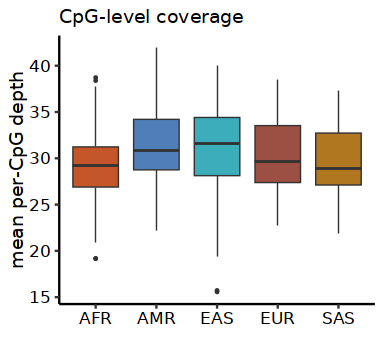

In [7]:
w <- 3.2; h <- 3
options(repr.plot.width = w, repr.plot.height = h)
pA <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = cpg_depth_mean, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) +
  scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'mean per-CpG depth', title = 'CpG-level coverage') +
  base_theme
ggsave(paste0(outdir, '/s1a_cpg_depth_by_superpop.pdf'), pA, width = w, height = h, device = cairo_pdf)
pA

### B: molecule-level coverage — reads per haplotype and read span

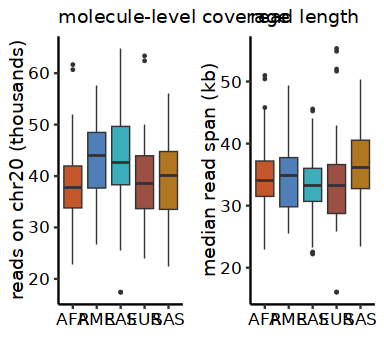

In [8]:
pB1 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = n_reads / 1e3, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'reads on chr20 (thousands)', title = 'molecule-level coverage') + base_theme
pB2 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = median_span_kb, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'median read span (kb)', title = 'read length') + base_theme
ggsave(paste0(outdir, '/s1b_molecule_coverage.pdf'), plot_grid(pB1, pB2, nrow = 1), width = 6.4, height = 3, device = cairo_pdf)
plot_grid(pB1, pB2, nrow = 1)

### C: number of CpGs observed per haplotype (hg38-mapped)

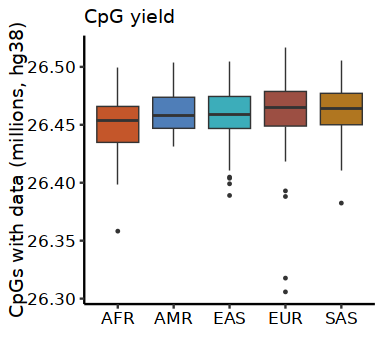

In [9]:
pC <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = n_cpg_hg38 / 1e6, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'CpGs with data (millions, hg38)', title = 'CpG yield') + base_theme
ggsave(paste0(outdir, '/s1c_n_cpgs.pdf'), pC, width = 3.2, height = 3, device = cairo_pdf)
pC

### D: global mCG by superpopulation and by ONT chemistry

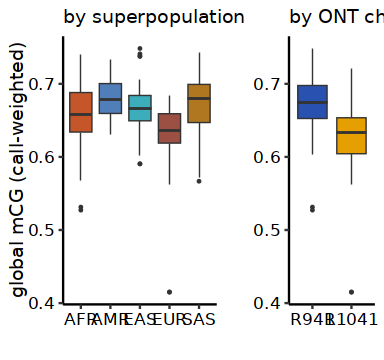

In [10]:
pD1 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = mcg_callweighted, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'global mCG (call-weighted)', title = 'by superpopulation') + base_theme
pD2 <- ggplot(hap[!is.na(sequencing_chemistry_ont)], aes(x = sequencing_chemistry_ont, y = mcg_callweighted,
                                                         fill = sequencing_chemistry_ont)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = chem_hexes) +
  labs(x = '', y = '', title = 'by ONT chemistry') + base_theme
ggsave(paste0(outdir, '/s1d_global_mcg.pdf'), plot_grid(pD1, pD2, nrow = 1, rel_widths = c(1, 0.7)),
       width = 5.6, height = 3, device = cairo_pdf)
plot_grid(pD1, pD2, nrow = 1, rel_widths = c(1, 0.7))

### E: het SNPs — genome-wide count per donor, and spacing between het sites

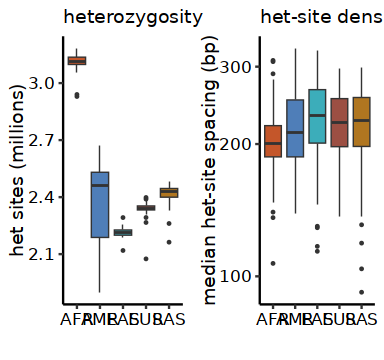

In [11]:
pE1 <- ggplot(donor[!is.na(superpopulation)], aes(x = superpopulation, y = n_het_snps_genome / 1e6, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'het sites (millions)', title = 'heterozygosity') + base_theme
pE2 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = median_het_spacing_bp, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  scale_y_log10() + labs(x = '', y = 'median het-site spacing (bp)', title = 'het-site density') + base_theme
ggsave(paste0(outdir, '/s1e_het_snps.pdf'), plot_grid(pE1, pE2, nrow = 1), width = 6.4, height = 3, device = cairo_pdf)
plot_grid(pE1, pE2, nrow = 1)

### F: het-SNP x CpG linkages observed on actual molecules

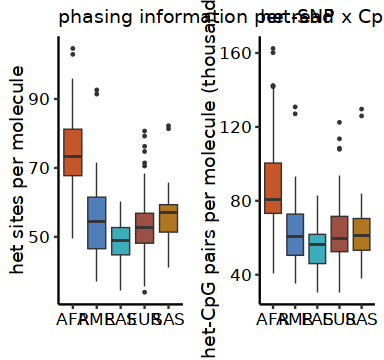

In [12]:
pF1 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = mean_het_per_read, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'het sites per molecule', title = 'phasing information per read') + base_theme
pF2 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = linkages_per_read / 1e3, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = 'het-CpG pairs per molecule (thousands)', title = 'het-SNP x CpG linkage') + base_theme
ggsave(paste0(outdir, '/s1f_linkages.pdf'), plot_grid(pF1, pF2, nrow = 1), width = 6.6, height = 3, device = cairo_pdf)
plot_grid(pF1, pF2, nrow = 1)

### G: cost of the het-site read filter (fraction of reads preserved)

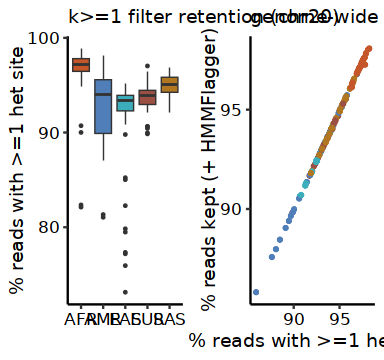

In [13]:
pG1 <- ggplot(hap[!is.na(superpopulation)], aes(x = superpopulation, y = 100 * frac_reads_ge1_het, fill = superpopulation)) +
  geom_boxplot(outlier.size = 0.3, lwd = 0.3) + scale_fill_manual(values = sp_hexes) +
  labs(x = '', y = '% reads with >=1 het site', title = 'k>=1 filter retention (chr20)') + base_theme
pG2 <- ggplot(donor[!is.na(superpopulation)], aes(x = 100 * frac_reads_het, y = 100 * frac_reads_kept, color = superpopulation)) +
  geom_point_rast(size = 0.9) + scale_color_manual(values = sp_hexes) +
  labs(x = '% reads with >=1 het site', y = '% reads kept (+ HMMFlagger)', title = 'genome-wide retention') + base_theme
ggsave(paste0(outdir, '/s1g_read_retention.pdf'), plot_grid(pG1, pG2, nrow = 1), width = 6.6, height = 3, device = cairo_pdf)
plot_grid(pG1, pG2, nrow = 1)

### H: hap1 vs hap2 global mCG

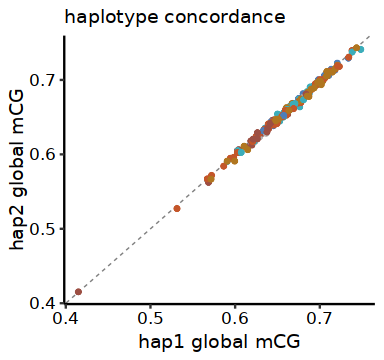

In [14]:
pH <- ggplot(donor, aes(x = mcg_callweighted_hap1, y = mcg_callweighted_hap2, color = superpopulation)) +
  geom_abline(slope = 1, intercept = 0, linetype = 'dashed', color = 'grey50', linewidth = 0.3) +
  geom_point_rast(size = 1.1) + scale_color_manual(values = sp_hexes, na.value = 'grey70') +
  labs(x = 'hap1 global mCG', y = 'hap2 global mCG', title = 'haplotype concordance') + base_theme
ggsave(paste0(outdir, '/s1h_hap1_vs_hap2_mcg.pdf'), pH, width = 3.4, height = 3.2, device = cairo_pdf)
pH

### I: donors on the classic 1000G PCA (full 3,202-sample panel as background)

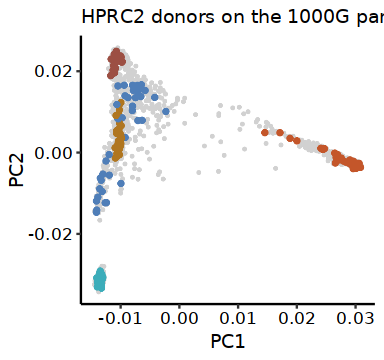

In [15]:
full_path <- '/u/project/cluo/terencew/claude/reference/1000G/pca/g1k_full/pca_result.eigenvec'
ped <- fread('/u/project/cluo/terencew/claude/reference/1000G/tsv/meta/g1k_3202_samples_ped_population.txt')
if (file.exists(full_path)) {
  ev <- fread(full_path, header = FALSE)
  setnames(ev, c('FID', 'IID', paste0('PC', 1:(ncol(ev) - 2))))
  ev <- merge(ev, ped[, .(IID = SampleID, Superpopulation)], by = 'IID', all.x = TRUE)
  ev[, in_hprc2 := IID %in% donor$sample]
  ev$Superpopulation <- factor(ev$Superpopulation, levels = sp_order)
  set.seed(1)
  ev <- ev[sample(nrow(ev))]
  pI <- ggplot(ev, aes(x = PC1, y = PC2)) +
    geom_point_rast(data = ev[in_hprc2 == FALSE], color = 'grey82', size = 0.5) +
    geom_point_rast(data = ev[in_hprc2 == TRUE], aes(color = Superpopulation), size = 1.2) +
    scale_color_manual(values = sp_hexes, na.value = 'grey40') +
    labs(x = 'PC1', y = 'PC2', title = 'HPRC2 donors on the 1000G panel (n=3,202 grey)') + base_theme
  ggsave(paste0(outdir, '/s1i_1000g_pca.pdf'), pI, width = 3.6, height = 3.2, device = cairo_pdf)
  pI
} else {
  cat('full-panel PCA not ready (job P01_1000g_full_pca); falling back to the 221-donor PCA\n')
  pI <- ggplot(donor[!is.na(PC1)], aes(x = PC1, y = PC2, color = superpopulation)) +
    geom_point_rast(size = 1.2) + scale_color_manual(values = sp_hexes) +
    labs(x = 'PC1', y = 'PC2', title = 'HPRC2 donors, ancestry PCA') + base_theme
  ggsave(paste0(outdir, '/s1i_1000g_pca.pdf'), pI, width = 3.6, height = 3.2, device = cairo_pdf)
  pI
}

### legend and assembled supplementary figure

Warning message in get_plot_component(plot, "guide-box"):
"Multiple components found; returning the first one. To return all, use `return_all = TRUE`."


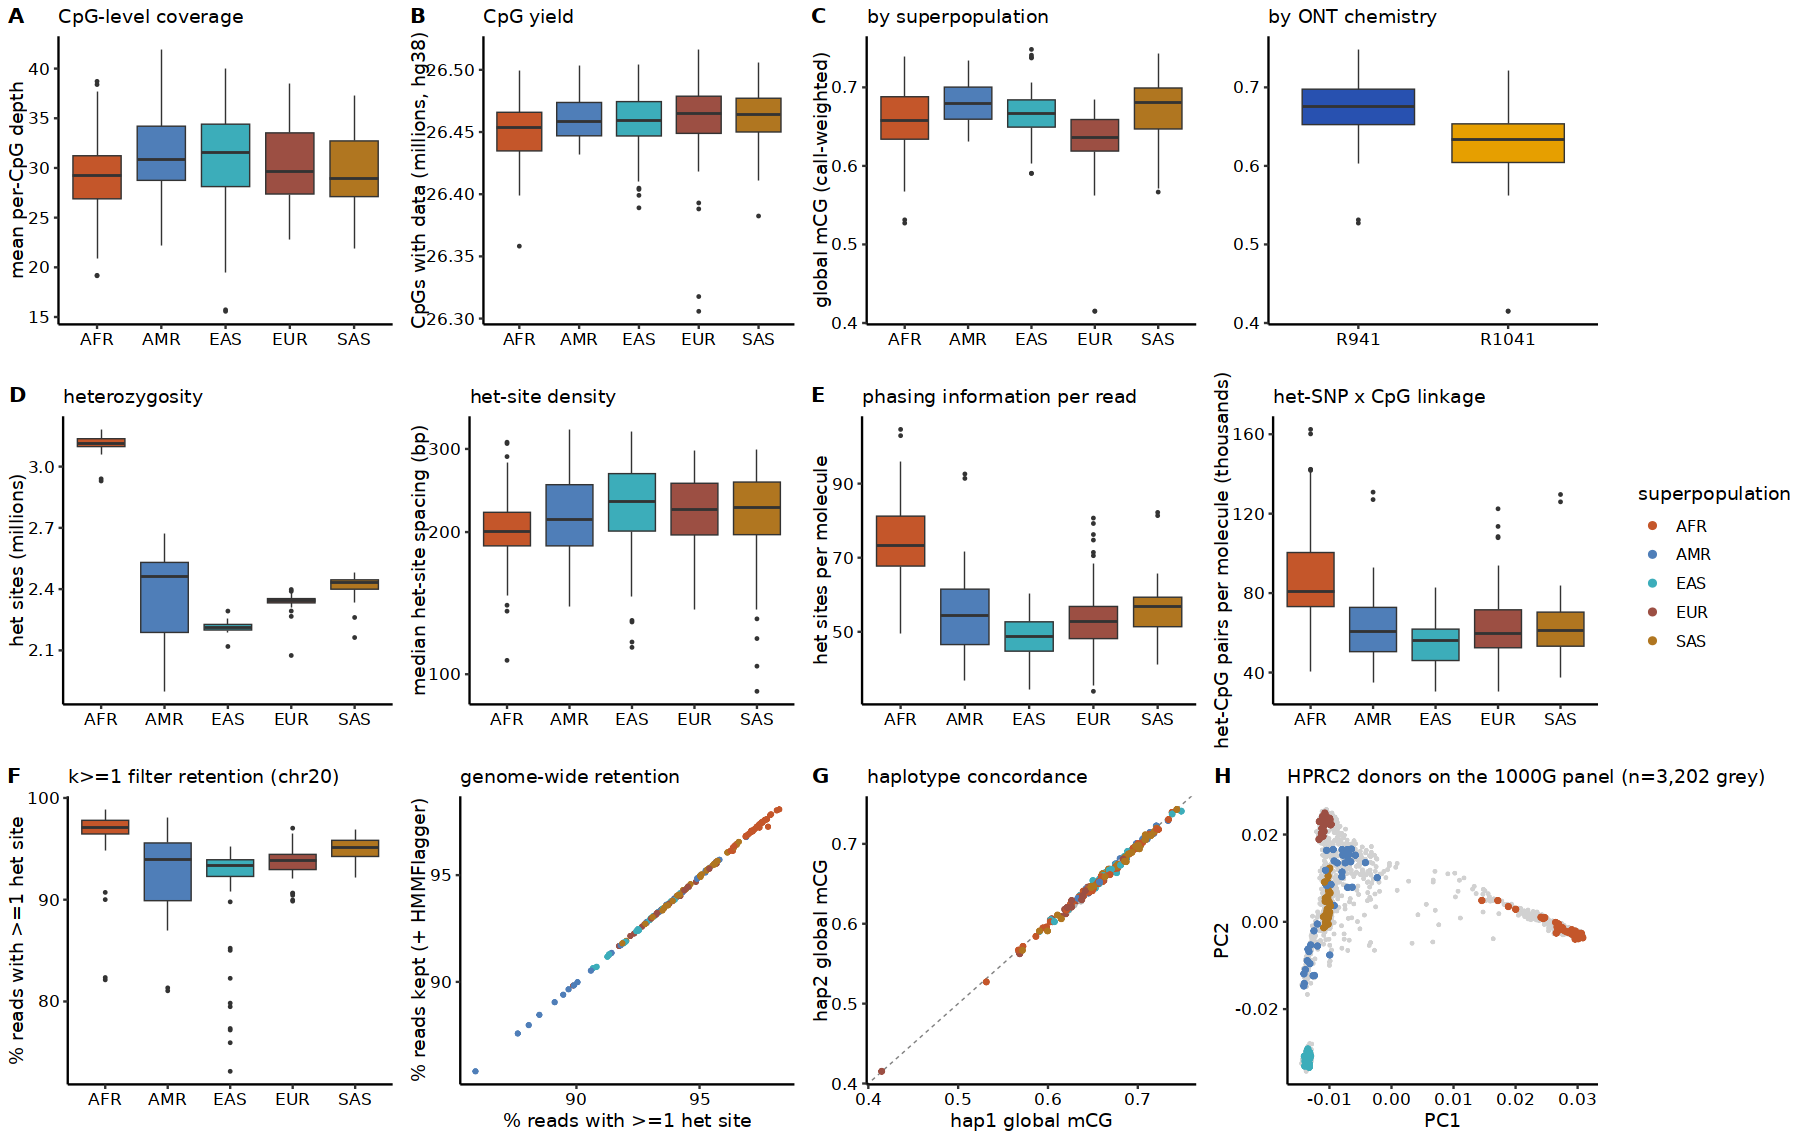

In [16]:
leg_sp <- get_legend(ggplot(donor[!is.na(superpopulation)], aes(x = PC1, y = PC2, color = superpopulation)) +
                       geom_point() + scale_color_manual(values = sp_hexes, name = 'superpopulation') +
                       theme_bw() + theme(legend.position = 'right', legend.text = element_text(size = 9)))
top <- plot_grid(pA, pC, pD1, pD2, nrow = 1, labels = c('A', 'B', 'C', ''), label_size = 12)
mid <- plot_grid(pE1, pE2, pF1, pF2, nrow = 1, labels = c('D', '', 'E', ''), label_size = 12)
bot <- plot_grid(pG1, pG2, pH, pI, nrow = 1, labels = c('F', '', 'G', 'H'), label_size = 12)
fig <- plot_grid(top, mid, bot, ncol = 1)
fig <- plot_grid(fig, leg_sp, nrow = 1, rel_widths = c(1, 0.12))
ggsave(paste0(outdir, '/figure_s1_full.pdf'), fig, width = 15, height = 9.5, device = cairo_pdf)
options(repr.plot.width = 15, repr.plot.height = 9.5)
fig

In [17]:
sessionInfo()

R version 4.1.0 (2021-05-18)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /u/project/cluo/terencew/miniconda3/envs/allcools/lib/libmkl_gf_lp64.so.2

locale:
[1] C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] forcats_0.5.2     stringr_1.6.0     dplyr_1.1.4       purrr_1.2.2      
 [5] readr_2.1.5       tidyr_1.3.2       tibble_3.2.1      tidyverse_1.3.2  
 [9] repr_1.1.4        scales_1.4.0      ggrastr_1.0.2     data.table_1.14.4
[13] cowplot_1.1.1     ggplot2_3.5.0    

loaded via a namespace (and not attached):
 [1] lubridate_1.9.3     assertthat_0.2.1    digest_0.6.35      
 [4] utf8_1.2.4          IRdisplay_1.1       R6_2.5.1           
 [7] cellranger_1.1.0    backports_1.4.1     reprex_2.0.2       
[10] evaluate_0.23       httr_1.4.7          pillar_1.9.0       
[13] rlang_1.1.4         googlesheets4_1.0.1 uuid_1.1-0         
[

In [18]:
Sys.time()

[1] "2026-09-18 00:13:34 PDT"